In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Load and Understand Data

In [5]:
df = pd.read_csv("et.csv")
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [7]:
df.shape

(277, 11)

In [9]:
df.columns

Index(['Date', 'Account', 'Category', 'Subcategory', 'Note', 'INR',
       'Income/Expense', 'Note.1', 'Amount', 'Currency', 'Account.1'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    str    
 1   Account         277 non-null    str    
 2   Category        277 non-null    str    
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    str    
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    str    
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    str    
 10  Account.1       277 non-null    float64
dtypes: float64(5), str(6)
memory usage: 23.9 KB


In [13]:
df.describe()

,Subcategory,INR,Note.1,Amount,Account.1
count,0.0,277.000000,0.0,277.000000,277.000000
mean,NaN,410.750903,NaN,406.759134,406.759134
std,NaN,1065.756569,NaN,1065.158318,1065.158318
min,NaN,3.000000,NaN,3.000000,3.000000
25%,NaN,50.000000,NaN,50.000000,50.000000
50%,NaN,128.000000,NaN,125.000000,125.000000
75%,NaN,301.150000,NaN,300.000000,300.000000
max,NaN,10000.000000,NaN,10000.000000,10000.000000


Date                0.00
Account             0.00
Category            0.00
Subcategory       100.00
Note                1.44
INR                 0.00
Income/Expense      0.00
Note.1            100.00
Amount              0.00
Currency            0.00
Account.1           0.00
dtype: float64


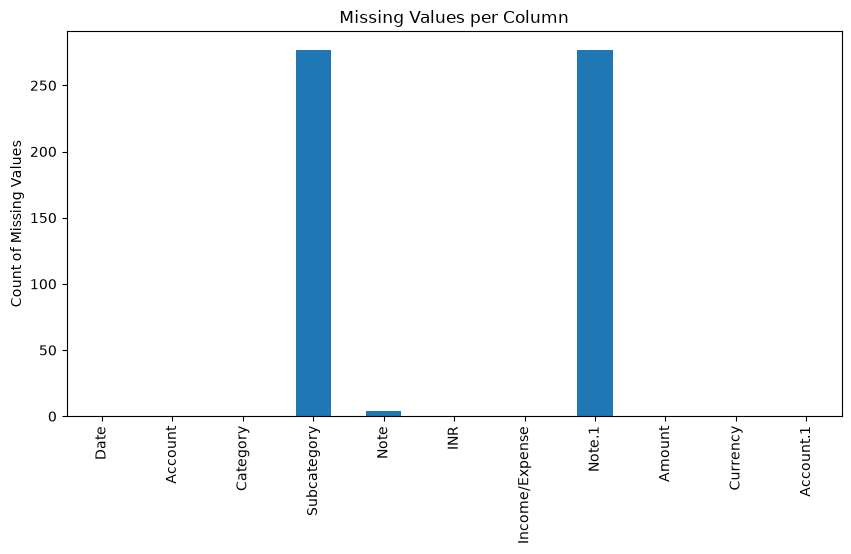

In [21]:
df.isnull().sum()

# Percentage of nulls per column
print((df.isnull().sum() / len(df) * 100).round(2))

#Visualize where nulls are
import matplotlib.pyplot as plt

df.isnull().sum().plot(kind='bar', figsize=(10,5))
plt.title("Missing Values per Column")
plt.ylabel("Count of Missing Values")
plt.show()


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.dtypes

Date                  str
Account               str
Category              str
Subcategory       float64
Note                  str
INR               float64
Income/Expense        str
Note.1            float64
Amount            float64
Currency              str
Account.1         float64
dtype: object

Here date column is stored as string so need to fix

Analyze the Data

In [29]:
# Total expenses
total_expense = df['Amount'].sum()
print(f"Total Expenses: {total_expense:,.2f}")


Total Expenses: 112,672.28


In [31]:
# avg,min,max
print(f"Average Expense: {df['Amount'].mean():,.2f}")
print(f"Maximum Expense: {df['Amount'].max():,.2f}")
print(f"Minimum Expense: {df['Amount'].min():,.2f}")


Average Expense: 406.76
Maximum Expense: 10,000.00
Minimum Expense: 3.00


In [33]:
# Highest spending category
category_totals = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
print("\nSpending by category (highest first):")
print(category_totals)
print(f"\nHighest spending category: {category_totals.idxmax()} ({category_totals.max():,.2f})")


Spending by category (highest first):
Category
Other               37868.00
Food                23396.76
Allowance           14000.00
Household           12188.00
Transportation       9203.80
Salary               8000.00
Apparel              3388.00
Social Life          2513.72
Education            1400.00
Self-development      400.00
Beauty                196.00
Gift                  115.00
Petty cash              3.00
Name: Amount, dtype: float64

Highest spending category: Other (37,868.00)


In [34]:
# Count of transactions by category
category_counts = df['Category'].value_counts()
print("\nTransaction count by category:")
print(category_counts)


Transaction count by category:
Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64


Even though the other category has highest spending, but the food category is the category with most transaction

Visualize data

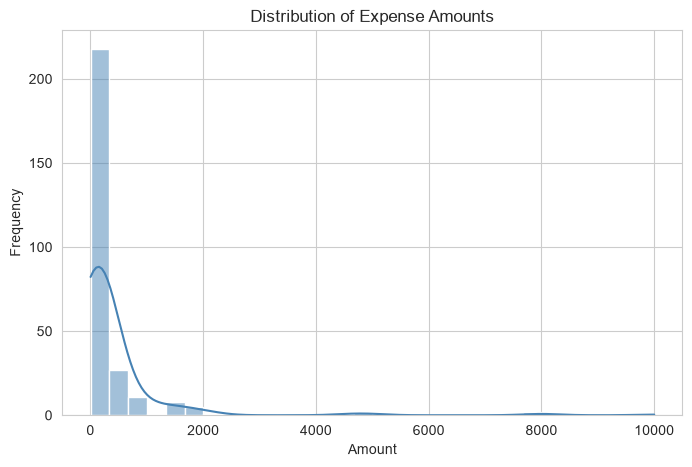

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Amount'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Expense Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

Distribution is right‑skewed (many small expenses, few large ones).
Peak/mode occurs near 0 (small amounts dominate).
Long tail extends toward higher amounts (large expenses are rare).

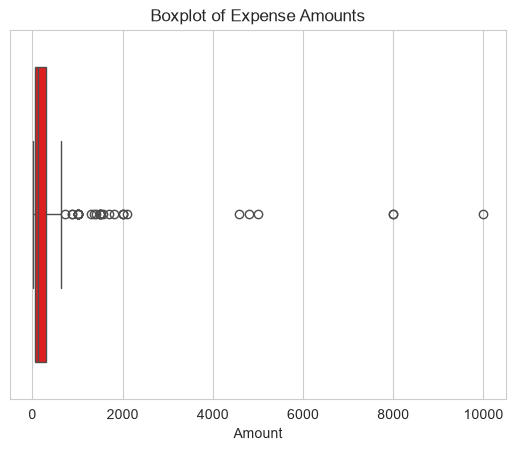

In [39]:

sns.boxplot(x=df['Amount'], color='red')
plt.title('Boxplot of Expense Amounts')
plt.show()

Box shows middle 50% of expenses (IQR) → clustered at low amounts.
Outliers (≈4–5) at 2k, 4k, 8k, 10k → rare but significant large expenses.
Typical spending is small and stable; few extreme values stretch the scale.